http://darribas.org/gds15/content/labs/lab_03.html

In [1]:
import seaborn as sns
import csv
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import pylab 
import scipy.stats as stats
import gmaps 
import gmaps.datasets 
import pyproj
import shapely
import zipfile
import requests
import io
#import mapclassify

from ipyleaflet import Map, basemaps, basemap_to_tiles
from IPython.display import display, Latex, Markdown, IFrame

# Default plot configurations
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12.0, 12.0)
sns.set()

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/dask/config.py:168: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  data = yaml.load(f.read()) or {}
/Users/rosskalter/anaconda2/lib/python2.7/site-packages/distributed/config.py:20: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  defaults = yaml.load(f)


In [2]:
# Name of the ZIP file
url = 'pirapo_11_algodao_clip.zip'

# Set the file path to appropriate location
local_path = 'data/pirapo/'

print('Downloading shapefile...')
zf = zipfile.ZipFile(local_path + url)
print("Done")

# Extract to folder
zf.extractall(path=local_path) 

# Print the filenames contained in the folder
filenames = [y for y in sorted(zf.namelist())] 
print(filenames)

Done
['pirapo_11_algodao_clip.dbf', 'pirapo_11_algodao_clip.prj', 'pirapo_11_algodao_clip.qix', 'pirapo_11_algodao_clip.qpj', 'pirapo_11_algodao_clip.shp', 'pirapo_11_algodao_clip.shx']


In [3]:
#contents of ZIP file
zf.namelist()

['pirapo_11_algodao_clip.dbf',
 'pirapo_11_algodao_clip.prj',
 'pirapo_11_algodao_clip.qix',
 'pirapo_11_algodao_clip.qpj',
 'pirapo_11_algodao_clip.shp',
 'pirapo_11_algodao_clip.shx']

In [4]:
# Assign filenames to variables for future access
dbf, prj, qix, qpj, shp, shx = [filename for filename in filenames]

In [5]:
# Read in the SHP file
data = gpd.read_file(local_path + shp)

# Display some important proporties for future analysis
print("Shape of the dataframe: {}".format(data.shape))
print("Projection of dataframe: {}".format(data.crs))

# Show the first 5 records in dataframe
data.head() 

Shape of the dataframe: (154149, 13)
Projection of dataframe: {u'init': u'epsg:4326'}


,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,Elevation,IsoTime,geometry
0,1.250782,1.524,4.811164,1458,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.19998886071195 -13.83705880575909 0)
1,1.250782,1.524,4.811164,1459,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20000168781748 -13.83706453203675 0)
2,1.250782,1.524,4.811164,1460,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20001451492361 -13.83707025831374 0)
3,1.270782,1.524,28.514902,1458,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19998405642441 -13.8370695107892 0)
4,1.270782,1.524,28.514902,1459,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19999698581748 -13.83707501303677 0)


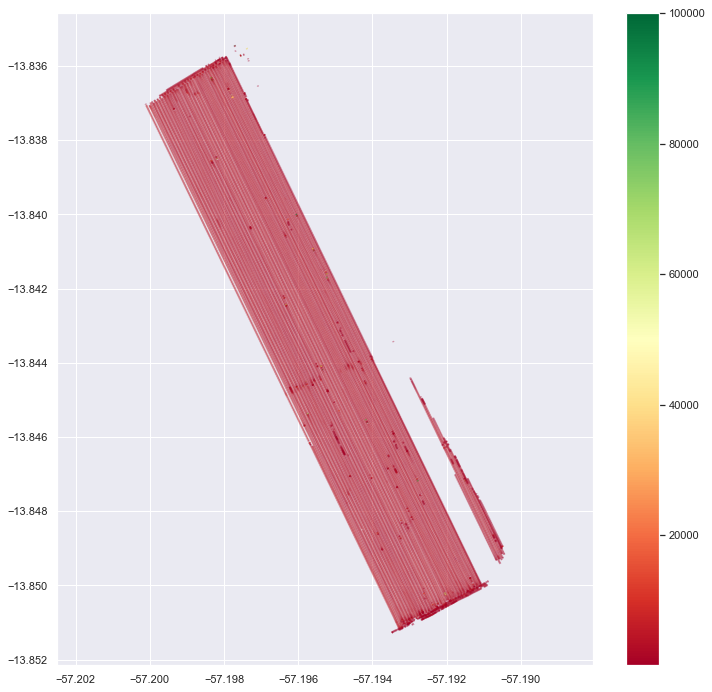

In [6]:
f, ax = plt.subplots(1, figsize=(12, 12))
ax = data.plot(ax=ax, column='WetMass', markersize=0.01, vmax=100000, legend=True, cmap='RdYlGn')
lims = plt.axis('equal')
plt.show()
#'Box_Plot', 'Equal_Interval', 'Fisher_Jenks', 'Fisher_Jenks_Sampled',
#'HeadTail_Breaks', 'Jenks_Caspall', 'Jenks_Caspall_Forced',
#'Jenks_Caspall_Sampled', 'Max_P_Classifier', 'Maximum_Breaks',
#'Natural_Breaks', 'Quantiles', 'Percentiles', 'Std_Mean',
#'User_Defined'

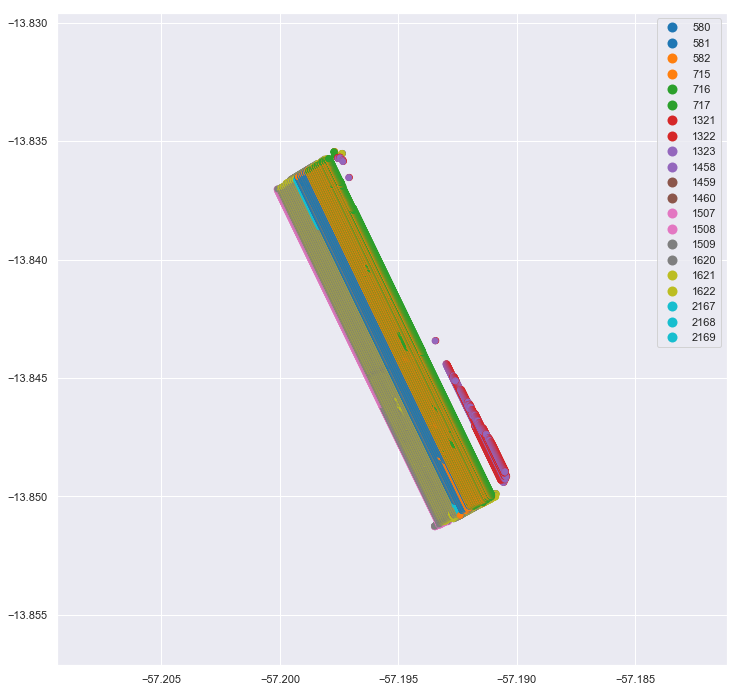

In [7]:
f, ax = plt.subplots(1, figsize=(12, 12))
ax = data.plot(ax=ax, column='SECTIONID', legend=True, categorical=True)
lims = plt.axis('equal')
plt.show()

In [8]:
data.groupby('SECTIONID').size()

SECTIONID
580      8526
581      8526
582      8526
715     19870
716     19870
717     19870
1321     1620
1322     1620
1323     1620
1458      482
1459      482
1460      482
1507     1553
1508     1553
1509     1553
1620    18315
1621    18315
1622    18315
2167     1017
2168     1017
2169     1017
dtype: int64

In [9]:
data.groupby('SECTIONID').mean()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,Crop,WetMass,Moisture,Heading,Elevation
SECTIONID,,,,,,,,
580,2.229952,1.524,20.156082,175,4388.386562,99.999992,249.970465,552.512821
581,2.229952,1.524,20.156082,175,4388.386562,99.999992,249.970465,552.512821
582,2.229952,1.524,20.156082,175,4388.386562,99.999992,249.970465,552.512821
715,2.104313,1.524,18.821814,175,4097.886628,99.999992,244.702640,553.096334
716,2.104313,1.524,18.821814,175,4097.886628,99.999992,244.702640,553.096334
717,2.104313,1.524,18.821814,175,4097.886628,99.999992,244.702640,553.096334
1321,2.101015,1.524,15.789283,175,3437.642141,99.999992,227.941429,553.378249
1322,2.101015,1.524,15.789283,175,3437.642141,99.999992,227.941429,553.378249
1323,2.101015,1.524,15.789283,175,3437.642141,99.999992,227.941429,553.378249


In [10]:
#import mplleaflet
#ax = data.plot(column='WetMass', markersize=0.01, vmax=100000)
#mplleaflet.show(fig=ax.figure, crs=data.crs, path='smap.html')

In [11]:
data.head()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,Elevation,IsoTime,geometry
0,1.250782,1.524,4.811164,1458,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.19998886071195 -13.83705880575909 0)
1,1.250782,1.524,4.811164,1459,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20000168781748 -13.83706453203675 0)
2,1.250782,1.524,4.811164,1460,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20001451492361 -13.83707025831374 0)
3,1.270782,1.524,28.514902,1458,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19998405642441 -13.8370695107892 0)
4,1.270782,1.524,28.514902,1459,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19999698581748 -13.83707501303677 0)


In [12]:
from __future__ import division 
import numpy as np
import matplotlib.pyplot as plt

def iwd(df, v):
    size = df.shape[0]
    df['predicted'] = np.zeros(size)
    for i in df.index:
        point = data.geometry[i]
        distances = df.distance(point).drop(i)
        num = sum(df[v].drop(i) / distances)
        denom = sum(1 / distances)
        prediction = num/denom
        
        df.loc[i, 'predicted'] = prediction
        
    return df

In [13]:
# Predicting WetMass using first 100 points with WetMass below 10000 (reduce outliers)
below_ten_thousand = data[data['WetMass'] < 10000]
top_hundred = below_ten_thousand.iloc[:100]
hundred = iwd(top_hundred, 'WetMass')
hundred[['WetMass', 'predicted']].head()

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  import sys
/Users/rosskalter/anaconda2/lib/python2.7/site-packages/pandas/core/indexing.py:543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item] = s


,WetMass,predicted
0,1047.463809,5560.604681
1,1047.463809,5437.501025
2,1047.463809,5561.353421
3,6208.245947,5371.334844
4,6208.245947,5339.711222


In [14]:
# Predicting WetMass using first 10000 points with WetMass above 2000 and below 6000 (reduce more outliers)
middle_values = data[(data['WetMass'] < 6000) & (data['WetMass'] > 2000)]
top_thousand = middle_values.iloc[:10000]
thousand = iwd(top_thousand, 'WetMass')
thousand[['WetMass', 'predicted']].head()

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  import sys


KeyboardInterrupt: 

NameError: name 'thousand' is not defined

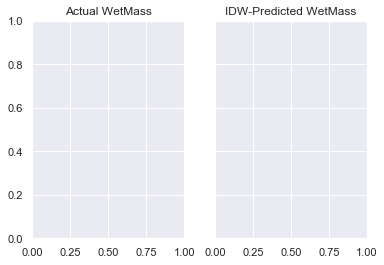

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True)
ax1.set_title('Actual WetMass')
ax2.set_title('IDW-Predicted WetMass')

thousand.plot(ax=ax1, column='WetMass', markersize=0.01, legend=True, cmap='RdYlGn')
thousand.plot(ax=ax2, column='predicted', markersize=0.01, legend=True, cmap='RdYlGn')

In [16]:
def plot_data(df):
    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True)
    ax1.set_title('Actual WetMass')
    ax2.set_title('IDW-Predicted WetMass')

    df.plot(ax=ax1, column='WetMass', markersize=0.01, legend=True, cmap='RdYlGn')
    df.plot(ax=ax2, column='predicted', markersize=0.01, legend=True, cmap='RdYlGn')

In [ ]:
# Predicting WetMass using ALL points with WetMass above 2000 and below 6000 (reduce more outliers)
all_filtered_data = data[(data['WetMass'] < 6000) & (data['WetMass'] > 2000)]
predicted_data = iwd(all_filtered_data, 'WetMass')
predicted_data[['WetMass', 'predicted']].head()

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  import sys


In [ ]:
plot_data(predicted_data)